11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Preprocessed training shape: (60000, 28, 28, 1)
Preprocessed testing shape: (10000, 28, 28, 1)


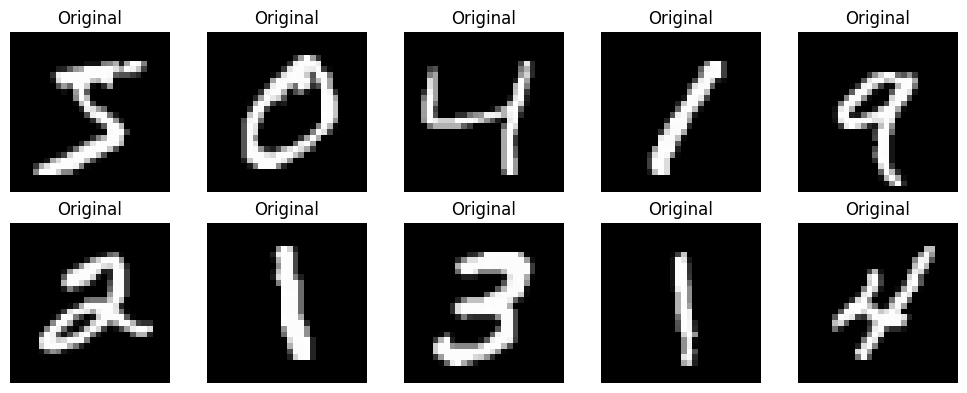


Autoencoder Architecture:


Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 143ms/step - loss: 0.1286 - val_loss: 0.0812
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 132ms/step - loss: 0.0787 - val_loss: 0.0756
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - loss: 0.0750 - val_loss: 0.0731
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 127ms/step - loss: 0.0732 - val_loss: 0.0718
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 134ms/step - loss: 0.0720 - val_loss: 0.0708
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 130ms/step - loss: 0.0711 - val_loss: 0.0701
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 128ms/step - loss: 0.0705 - val_loss: 0.0696
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - loss: 0.0700 - val_loss: 0.0693
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 127ms/step - loss: 0.0695 - val_loss: 0.0688
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 127ms/step - loss: 0.0691 - val_loss: 0.0684


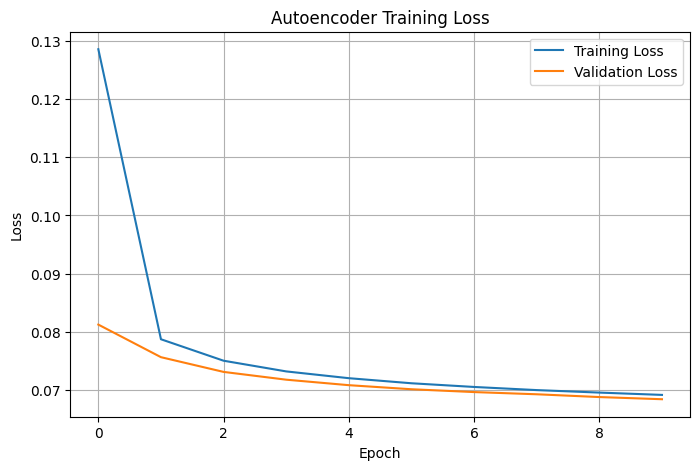


Encoded representation shape:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
(1, 7, 7, 16)
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


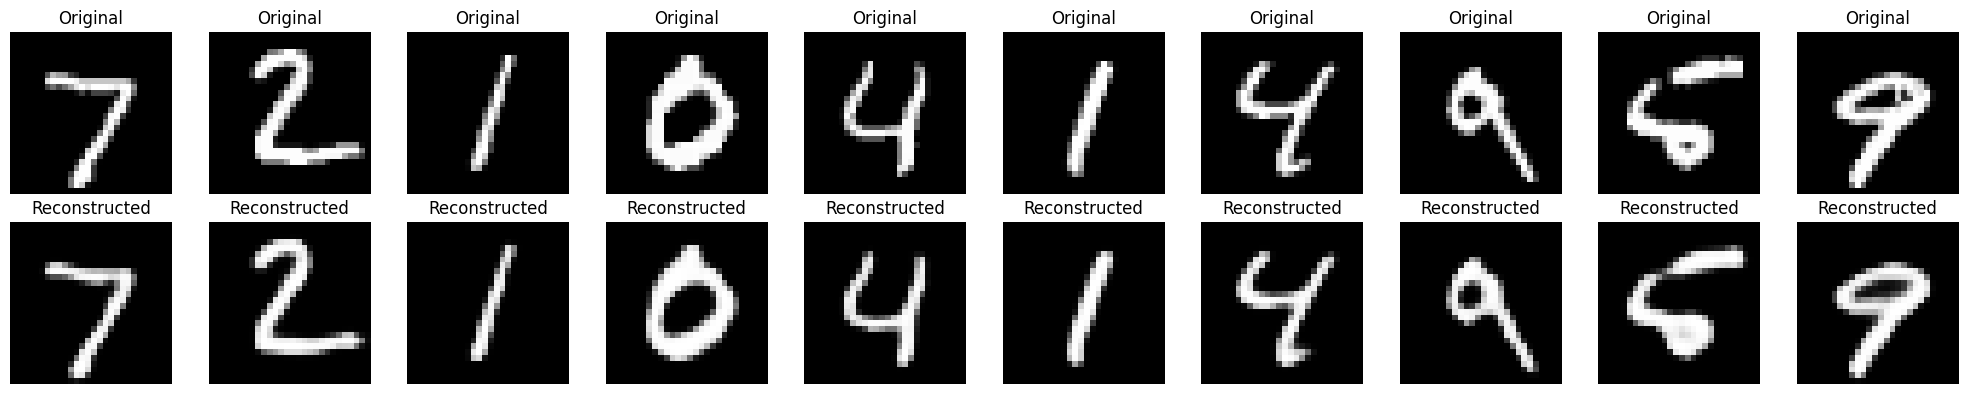

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Compressed representation shape:
(10, 7, 7, 16)


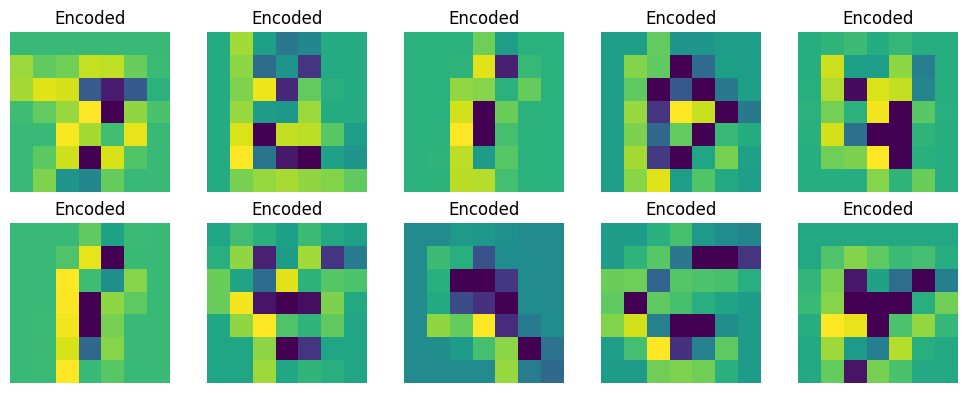


Mean Squared Reconstruction Error: 0.0027057093

Models saved successfully!


In [ ]:
# Convolutional Autoencoder on MNIST Dataset
# ---------------------------------------------------------
# Problem Statement:
# Implement a Convolutional Autoencoder to learn compressed
# image representations and reconstruct handwritten digits.
#
# Activities:
# 1. Build encoder-decoder architecture
# 2. Train autoencoder
# 3. Compare original and reconstructed images
# ---------------------------------------------------------

# ---------------------------------------------------------
# 1. Import Libraries
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)


# ---------------------------------------------------------
# 2. Load MNIST Dataset
# ---------------------------------------------------------

(x_train, _), (x_test, _) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


# ---------------------------------------------------------
# 3. Preprocess Data
# ---------------------------------------------------------

# Normalize pixel values from [0, 255] to [0, 1]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
# Original shape: (samples, 28, 28)
# New shape:      (samples, 28, 28, 1)

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Preprocessed training shape:", x_train.shape)
print("Preprocessed testing shape:", x_test.shape)


# ---------------------------------------------------------
# 4. Display Original MNIST Images
# ---------------------------------------------------------

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Original")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. Build Convolutional Autoencoder
# ---------------------------------------------------------

input_img = Input(shape=(28, 28, 1))


# ---------------------------------------------------------
# Encoder
# ---------------------------------------------------------

# First convolution layer
x = Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(input_img)

# Reduce image size: 28x28 -> 14x14
x = MaxPooling2D(
    (2, 2),
    padding="same"
)(x)


# Second convolution layer
x = Conv2D(
    16,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

# Reduce image size: 14x14 -> 7x7
encoded = MaxPooling2D(
    (2, 2),
    padding="same",
    name="encoded"
)(x)


# ---------------------------------------------------------
# Decoder
# ---------------------------------------------------------

# Increase image size: 7x7 -> 14x14
x = Conv2D(
    16,
    (3, 3),
    activation="relu",
    padding="same"
)(encoded)

x = UpSampling2D(
    (2, 2)
)(x)


# Increase image size: 14x14 -> 28x28
x = Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = UpSampling2D(
    (2, 2)
)(x)


# Reconstruct original image
decoded = Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)


# ---------------------------------------------------------
# 6. Create Autoencoder Model
# ---------------------------------------------------------

autoencoder = Model(
    input_img,
    decoded,
    name="Convolutional_Autoencoder"
)

print("\nAutoencoder Architecture:")
autoencoder.summary()


# ---------------------------------------------------------
# 7. Compile Model
# ---------------------------------------------------------

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


# ---------------------------------------------------------
# 8. Train Autoencoder
# ---------------------------------------------------------

history = autoencoder.fit(
    x_train,
    x_train,                 # Input = target
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)


# ---------------------------------------------------------
# 9. Plot Training and Validation Loss
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# 10. Create Encoder Model
# ---------------------------------------------------------

encoder = Model(
    input_img,
    encoded,
    name="Encoder"
)

print("\nEncoded representation shape:")
print(encoder.predict(x_test[:1]).shape)


# ---------------------------------------------------------
# 11. Reconstruct Test Images
# ---------------------------------------------------------

decoded_images = autoencoder.predict(x_test)


# ---------------------------------------------------------
# 12. Compare Original and Reconstructed Images
# ---------------------------------------------------------

n = 10

plt.figure(figsize=(20, 4))

# Original images
for i in range(n):

    # Original image
    ax = plt.subplot(2, n, i + 1)

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")


    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        decoded_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Reconstructed")
    plt.axis("off")


plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 13. Display Compressed Representation
# ---------------------------------------------------------

encoded_images = encoder.predict(x_test[:10])

print("\nCompressed representation shape:")
print(encoded_images.shape)


# Display one encoded representation
plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    # Show the first feature channel
    plt.imshow(
        encoded_images[i, :, :, 0],
        cmap="viridis"
    )

    plt.title("Encoded")
    plt.axis("off")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 14. Calculate Reconstruction Error
# ---------------------------------------------------------

mse = np.mean(
    np.square(x_test - decoded_images)
)

print("\nMean Squared Reconstruction Error:", mse)


# ---------------------------------------------------------
# 15. Save the Autoencoder
# ---------------------------------------------------------

autoencoder.save(
    "mnist_convolutional_autoencoder.keras"
)

encoder.save(
    "mnist_encoder.keras"
)

print("\nModels saved successfully!")